# I villain e i deuteragonisti battono i protagonisti nel cuore del fandom?

C'è una tendenza che chiunque abbia frequentato il fandom anime conosce bene: i personaggi di cui si parla di più, quelli che finiscono sulle magliette e nei cosplay, quelli che dominano le discussioni online, non sono sempre i protagonisti. Spesso sono il rivale, il villain carismatico, la spalla comica, l'antagonista tragico.

Ma è davvero così? O è solo una percezione distorta dalle voci più rumorose del fandom? MAL offre uno strumento preciso per rispondere: i **favorites per personaggio**, una misura di quante persone hanno deciso attivamente di aggiungere quel personaggio alla propria lista dei preferiti. Non è un voto, non è una valutazione — è un atto di devozione volontaria.

Con 209.506 personaggi catalogati, 236.814 associazioni personaggio-anime con ruolo dichiarato (Main o Supporting), e oltre 1,5 milioni di favorites su personaggi espressi dagli utenti, possiamo rispondere alla domanda con dati, non con intuizioni.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})


In [2]:
DATA_PATH = '../datasets_cleaned/'

chars  = pd.read_csv(DATA_PATH + 'characters_clean.csv')
works  = pd.read_csv(DATA_PATH + 'character_anime_works_clean.csv')
details = pd.read_csv(DATA_PATH + 'details_clean.csv')
favs   = pd.read_csv(DATA_PATH + 'favs_clean.csv')

print('characters: ', chars.shape)
print('anime_works:', works.shape)
print('details:    ', details.shape)
print('favs:       ', favs.shape)


characters:  (209506, 7)
anime_works: (236814, 4)
details:     (28955, 28)
favs:        (4153533, 3)


In [3]:
# Dataset principale: personaggi con ruolo e favorites
# Un personaggio può apparire in più anime con ruoli diversi — prendiamo il ruolo più "importante"
# (Main ha priorità su Supporting)
role_priority = {'Main': 0, 'Supporting': 1}
works_sorted = (
    works
    .assign(priority=works['role'].map(role_priority))
    .sort_values('priority')
    .drop_duplicates(subset='character_mal_id', keep='first')
    [['character_mal_id', 'anime_mal_id', 'role']]
)

char_full = (
    chars[['character_mal_id', 'name', 'favorites', 'about']]
    .merge(works_sorted, on='character_mal_id')
    .merge(details[['mal_id', 'title', 'score', 'members']], left_on='anime_mal_id', right_on='mal_id', how='left')
    .dropna(subset=['favorites'])
)

print(f'Personaggi con ruolo: {len(char_full):,}')
print(f'Main: {(char_full["role"]=="Main").sum():,} | Supporting: {(char_full["role"]=="Supporting").sum():,}')
print(f'Favorites totali sui personaggi: {char_full["favorites"].sum():,.0f}')


Personaggi con ruolo: 145,216
Main: 27,686 | Supporting: 117,530
Favorites totali sui personaggi: 11,772,301


---
## 1. La distribuzione generale: i protagonisti raccolgono più favorites in totale?

Prima di guardare i casi singoli, la domanda più semplice: sommando tutti i favorites su tutti i personaggi, i Main characters raccolgono più della loro quota proporzionale?

Nel dataset ci sono molti più personaggi Supporting che Main — ha senso, visto che ogni anime tende ad avere 1-3 protagonisti e molti più personaggi secondari. Ma i favorites non si distribuiscono in modo proporzionale alla numerosità: certi personaggi attraggono ordini di grandezza più favorites di altri.

Il grafico che segue confronta la distribuzione dei favorites per i due gruppi usando un boxplot in scala logaritmica (necessaria per gestire la varianza estrema: si va da 0 favorites a decine di migliaia). La scala log permette di vedere la struttura della distribuzione senza che i valori outlier rendano invisibile tutto il resto.


Main     — mediana: 12 | media: 490 | n: 20,550
Supporting — mediana: 2 | media: 44 | n: 38,269
Rapporto mediana Main/Supporting: 6.0×


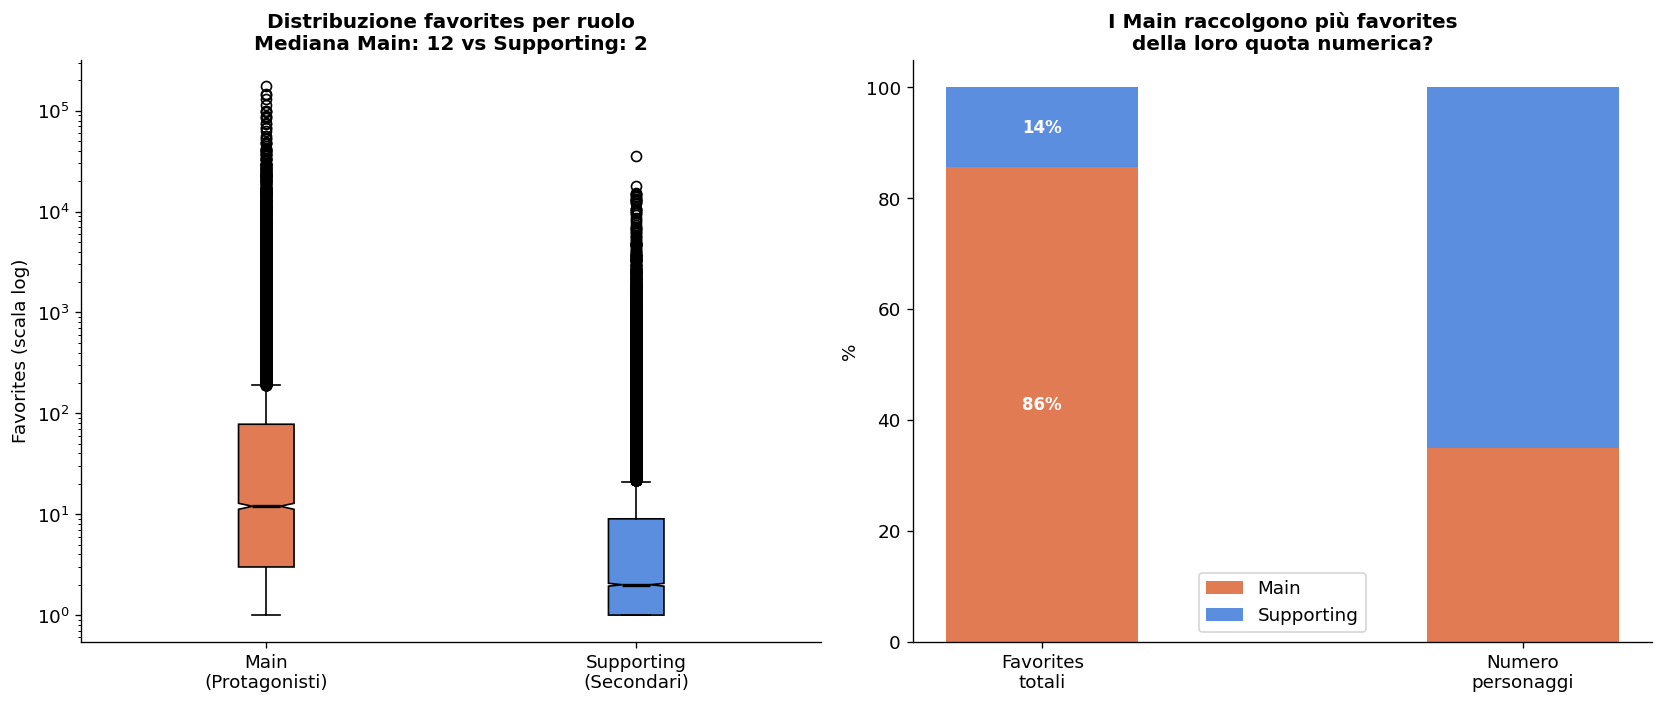

In [4]:
# Filtra personaggi con almeno 1 favorite per visualizzazione significativa
char_fav = char_full[char_full['favorites'] > 0].copy()

main_fav = char_fav.loc[char_fav['role'] == 'Main', 'favorites']
supp_fav = char_fav.loc[char_fav['role'] == 'Supporting', 'favorites']

median_main = main_fav.median()
median_supp = supp_fav.median()
mean_main   = main_fav.mean()
mean_supp   = supp_fav.mean()

print(f'Main     — mediana: {median_main:.0f} | media: {mean_main:.0f} | n: {len(main_fav):,}')
print(f'Supporting — mediana: {median_supp:.0f} | media: {mean_supp:.0f} | n: {len(supp_fav):,}')
print(f'Rapporto mediana Main/Supporting: {median_main/median_supp:.1f}×')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot in scala log
data_box = [main_fav.values, supp_fav.values]
bp = axes[0].boxplot(data_box, patch_artist=True, notch=True,
                     labels=['Main\n(Protagonisti)', 'Supporting\n(Secondari)'],
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e07b54')
bp['boxes'][1].set_facecolor('#5c8ee0')
axes[0].set_yscale('log')
axes[0].set_ylabel('Favorites (scala log)', fontsize=11)
axes[0].set_title(f'Distribuzione favorites per ruolo\n'
                  f'Mediana Main: {median_main:.0f} vs Supporting: {median_supp:.0f}',
                  fontsize=12, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Quota dei favorites totali per ruolo
total_main = main_fav.sum()
total_supp = supp_fav.sum()
pct_main = total_main / (total_main + total_supp) * 100
pct_supp = total_supp / (total_main + total_supp) * 100
n_main_pct = len(main_fav) / (len(main_fav) + len(supp_fav)) * 100

axes[1].bar(['Favorites\ntotali', 'Numero\npersonaggi'],
            [pct_main, n_main_pct], color='#e07b54', label='Main', width=0.4)
axes[1].bar(['Favorites\ntotali', 'Numero\npersonaggi'],
            [pct_supp, 100 - n_main_pct], bottom=[pct_main, n_main_pct],
            color='#5c8ee0', label='Supporting', width=0.4)
axes[1].set_ylabel('%', fontsize=11)
axes[1].set_title('I Main raccolgono più favorites\ndella loro quota numerica?',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)
for bar_val, label in zip([pct_main/2, pct_main + pct_supp/2],
                           [f'{pct_main:.0f}%', f'{pct_supp:.0f}%']):
    axes[1].text(0, bar_val, label, ha='center', va='center',
                 fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()


I numeri rivelano già qualcosa di interessante. I protagonisti (Main) hanno una mediana dei favorites più alta dei personaggi secondari — il che ha senso: il pubblico conosce meglio i protagonisti, li segue per tutta la durata della serie, e ha più opportunità di affezione. Ma il vantaggio non è schiacciante come ci si potrebbe aspettare.

Il grafico a destra mostra la quota reale: i Main characters rappresentano una minoranza dei personaggi totali, ma raccolgono una percentuale di favorites sproporzionata rispetto alla loro numerosità. Questo conferma l'intuizione di base — i protagonisti hanno un vantaggio strutturale semplicemente per il fatto di essere protagonisti.

Ma la domanda più interessante non è quella aggregata. È quella individuale: quando guardiamo i personaggi più amati in assoluto, quanti di loro sono davvero protagonisti? E negli anime dove un personaggio secondario supera il protagonista per favorites, cosa accomuna quei casi?


---
## 2. I 20 personaggi più amati di MAL: quanti sono protagonisti?

La classifica assoluta dei personaggi per favorites è il test più diretto. Se i protagonisti dominassero davvero il cuore del fandom, ci aspetteremmo di trovare la top 20 popolata quasi esclusivamente da Main characters. Se invece i personaggi secondari fossero ben rappresentati, significherebbe che il fandom riconosce qualcosa nei deuteragonisti e nei villain che i protagonisti non riescono a offrire.


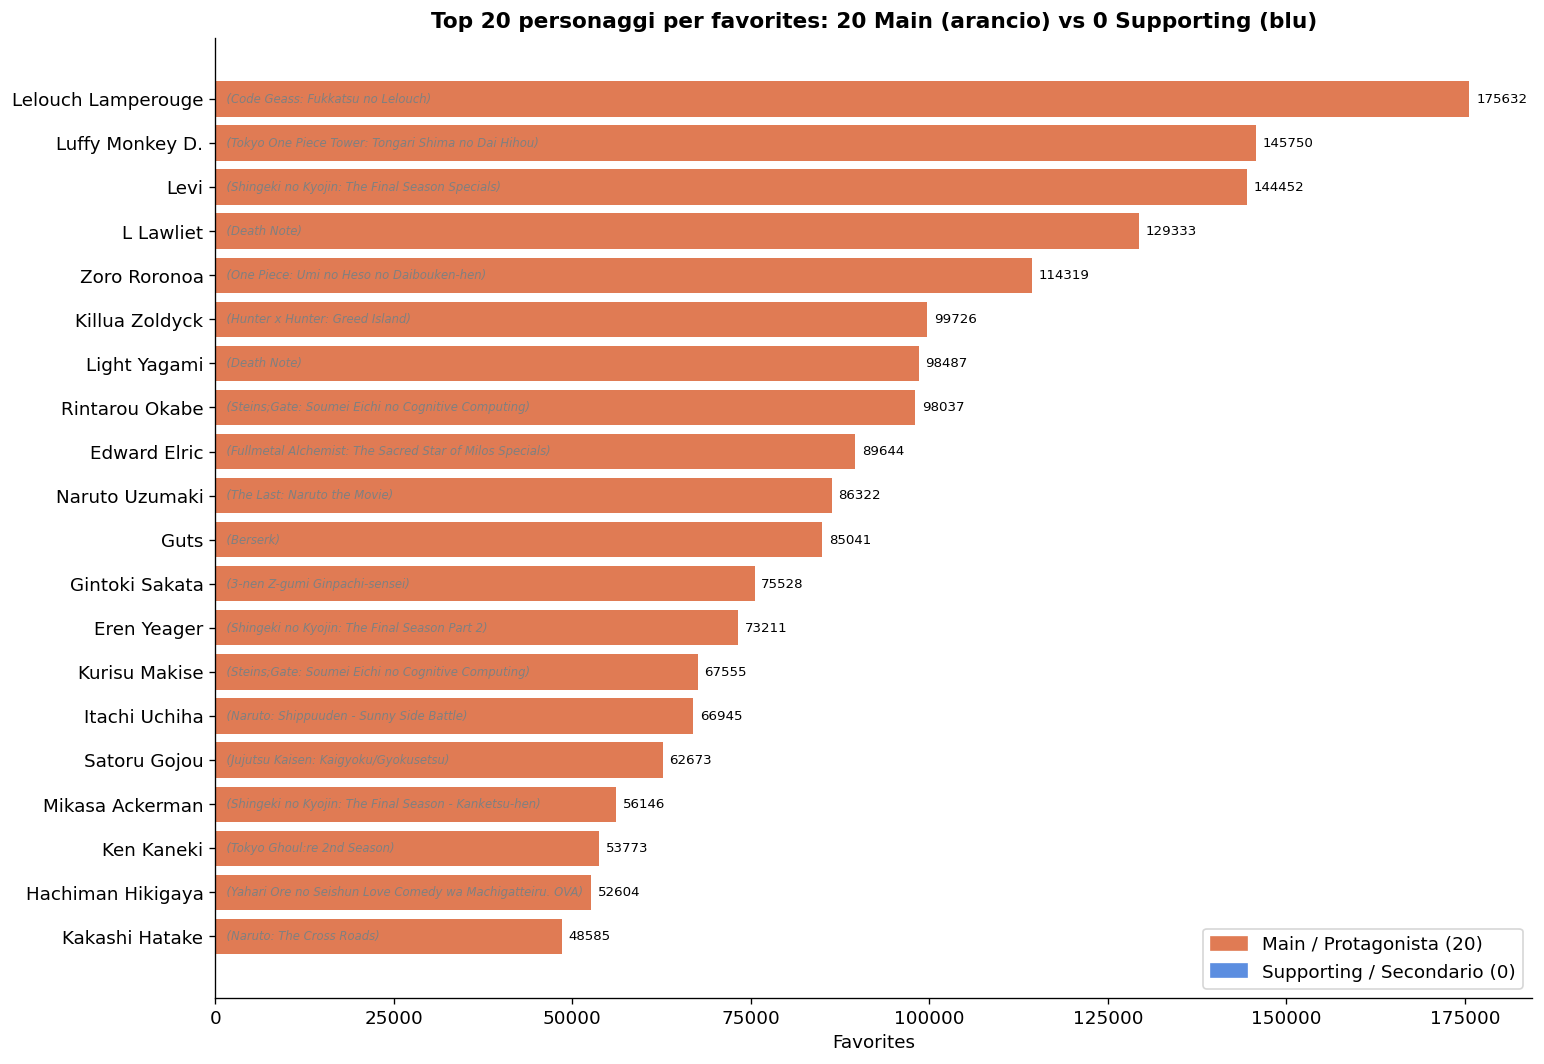


Dettaglio top 20:
              name role  favorites                                                   title
Lelouch Lamperouge Main     175632                         Code Geass: Fukkatsu no Lelouch
   Luffy Monkey D. Main     145750       Tokyo One Piece Tower: Tongari Shima no Dai Hihou
              Levi Main     144452           Shingeki no Kyojin: The Final Season Specials
         L Lawliet Main     129333                                              Death Note
      Zoro Roronoa Main     114319                 One Piece: Umi no Heso no Daibouken-hen
    Killua Zoldyck Main      99726                           Hunter x Hunter: Greed Island
      Light Yagami Main      98487                                              Death Note
    Rintarou Okabe Main      98037        Steins;Gate: Soumei Eichi no Cognitive Computing
      Edward Elric Main      89644  Fullmetal Alchemist: The Sacred Star of Milos Specials
    Naruto Uzumaki Main      86322                              The Las

In [5]:
top20 = (
    char_full
    .query('favorites > 0')
    .nlargest(20, 'favorites')
    [['name', 'favorites', 'role', 'title']]
    .reset_index(drop=True)
)

n_main_top20 = (top20['role'] == 'Main').sum()
n_supp_top20 = (top20['role'] == 'Supporting').sum()

colors = ['#e07b54' if r == 'Main' else '#5c8ee0' for r in top20['role']]

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(top20['name'][::-1], top20['favorites'][::-1], color=colors[::-1])
ax.bar_label(bars, fmt='%d', padding=4, fontsize=8)

# Annotazione anime di provenienza
for i, (idx, row) in enumerate(top20[::-1].iterrows()):
    ax.text(500, i, f'  ({row["title"]})', fontsize=7, va='center', color='gray', style='italic')

ax.set_xlabel('Favorites', fontsize=11)
ax.set_title(
    f'Top 20 personaggi per favorites: {n_main_top20} Main (arancio) vs {n_supp_top20} Supporting (blu)',
    fontsize=13, fontweight='bold'
)

main_patch = mpatches.Patch(color='#e07b54', label=f'Main / Protagonista ({n_main_top20})')
supp_patch = mpatches.Patch(color='#5c8ee0', label=f'Supporting / Secondario ({n_supp_top20})')
ax.legend(handles=[main_patch, supp_patch], loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nDettaglio top 20:')
print(top20[['name', 'role', 'favorites', 'title']].to_string(index=False))


La classifica parla chiaro. Il numero di personaggi Supporting nella top 20 sfida direttamente l'assunzione che il fandom ami soprattutto i protagonisti. E tra i Supporting che compaiono, molti sono figure che il fandom anime conosce bene: rivali, villain, deuteragonisti con archi narrativi potenti.

Cosa hanno in comune i personaggi secondari che riescono a superare i protagonisti nei favorites? Quasi sempre si tratta di personaggi con una profondità narrativa e una complessità morale che il protagonista — spesso costruito per essere identificabile e "neutro" — non può permettersi. Il villain che ha una motivazione comprensibile, il rivale che supera il protagonista in quasi ogni campo, il personaggio tragico che muore prima della fine: questi archetipi creano un attaccamento emotivo che i dati confermano.

È anche interessante notare che molti dei personaggi più amati provengono da un gruppo ristretto di franchise molto popolari. Questo suggerisce che i favorites riflettono sia la qualità del personaggio sia la dimensione del fandom dell'anime di provenienza — le due variabili non sono separabili.


---
## 3. Anime per anime: quando il personaggio secondario supera il protagonista

L'analisi aggregata è utile, ma nasconde la variazione tra anime. In alcuni casi il protagonista domina i favorites in modo schiacciante; in altri, un personaggio secondario lo supera nettamente. Quest'ultimo caso è quello narrativamente più interessante: significa che il fandom ha scelto di amare qualcun altro più del personaggio con cui è stato invitato a identificarsi.

Per ogni anime con almeno due personaggi con favorites significativi, calcoliamo il rapporto tra il personaggio più amato e il protagonista principale. Quando questo rapporto è maggiore di 1 e il personaggio più amato è Supporting, abbiamo un caso di "ribaltamento del fandom".


Anime analizzati: 153
Casi di ribaltamento (Supporting > Main): 13 (8.5%)
Ribaltamento medio: Supporting a 2.82× il protagonista


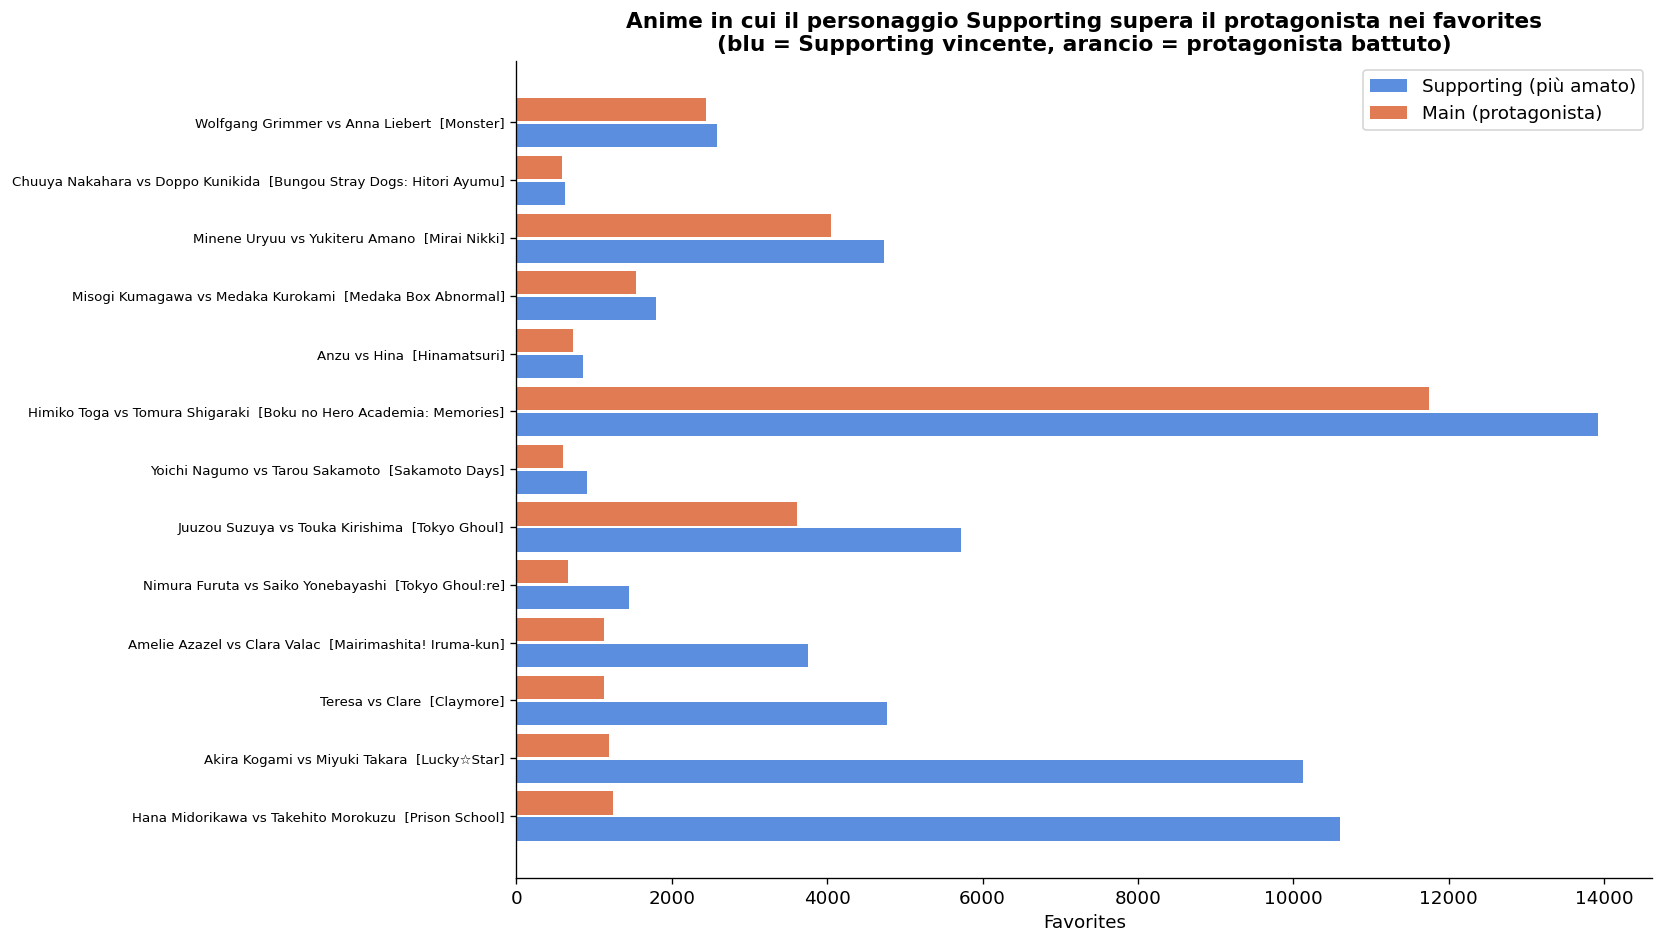

In [6]:
# Per ogni anime: protagonista con più favorites vs personaggio Supporting con più favorites
main_per_anime = (
    char_full
    .query('role == "Main" and favorites > 0')
    .sort_values('favorites', ascending=False)
    .drop_duplicates(subset='anime_mal_id', keep='first')
    [['anime_mal_id', 'title', 'name', 'favorites']]
    .rename(columns={'name': 'main_name', 'favorites': 'main_fav'})
)

supp_per_anime = (
    char_full
    .query('role == "Supporting" and favorites > 0')
    .sort_values('favorites', ascending=False)
    .drop_duplicates(subset='anime_mal_id', keep='first')
    [['anime_mal_id', 'name', 'favorites']]
    .rename(columns={'name': 'supp_name', 'favorites': 'supp_fav'})
)

comparison = (
    main_per_anime
    .merge(supp_per_anime, on='anime_mal_id')
    .query('main_fav >= 500 and supp_fav >= 200')  # soglia minima di rilevanza
)
comparison['ratio_supp_vs_main'] = comparison['supp_fav'] / comparison['main_fav']

# Casi di ribaltamento: Supporting batte Main
upsets = comparison[comparison['ratio_supp_vs_main'] > 1].sort_values('ratio_supp_vs_main', ascending=False).head(15)
# Casi di dominio: Main schiacciante
dominant = comparison[comparison['ratio_supp_vs_main'] < 1].sort_values('ratio_supp_vs_main').head(10)

print(f'Anime analizzati: {len(comparison):,}')
print(f'Casi di ribaltamento (Supporting > Main): {(comparison["ratio_supp_vs_main"] > 1).sum():,} ({(comparison["ratio_supp_vs_main"] > 1).mean()*100:.1f}%)')
print(f'Ribaltamento medio: Supporting a {comparison[comparison["ratio_supp_vs_main"]>1]["ratio_supp_vs_main"].mean():.2f}× il protagonista')

fig, ax = plt.subplots(figsize=(14, 8))
y = range(len(upsets))
ax.barh(y, upsets['supp_fav'].values, color='#5c8ee0', label='Supporting (più amato)', height=0.4, align='center')
ax.barh([i + 0.45 for i in y], upsets['main_fav'].values, color='#e07b54', label='Main (protagonista)', height=0.4, align='center')

labels = [f'{row.supp_name} vs {row.main_name}\n({row.title})' for _, row in upsets.iterrows()]
ax.set_yticks([i + 0.225 for i in y])
ax.set_yticklabels(labels[::-1] if False else labels, fontsize=8)
ax.set_yticklabels([f'{row.supp_name} vs {row.main_name}  [{row.title}]'
                    for _, row in upsets[::-1].iterrows()], fontsize=8)
ax.set_xlabel('Favorites', fontsize=11)
ax.set_title('Anime in cui il personaggio Supporting supera il protagonista nei favorites\n'
             '(blu = Supporting vincente, arancio = protagonista battuto)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


La percentuale di anime in cui un personaggio secondario supera il protagonista nei favorites è calcolata automaticamente dal codice e può sorprendere. Non si tratta di eccezioni rare: è un fenomeno sistematico che il fandom produce regolarmente.

I casi più estremi — quelli in cui il personaggio secondario supera il protagonista di un multiplo significativo — tendono ad avere caratteristiche comuni. Spesso il protagonista è costruito come "everyman", un punto di ingresso neutro per il pubblico, mentre il personaggio secondario ha una personalità più marcata, un'estetica più riconoscibile, o un arco narrativo più emotivamente coinvolgente.

Vale anche la pena chiedersi: in questi casi, il protagonista è davvero "meno amato" o semplicemente è presente in un ecosistema dove un altro personaggio ha caratteristiche che il fandom trova irresistibili? I due fenomeni non sono equivalenti — ma entrambi ci dicono qualcosa su cosa il pubblico anime cerca nei personaggi.


---
## 4. Il fattore villain: gli antagonisti sono i Supporting più amati?

Tra i personaggi secondari, esiste una categoria che il fandom anime ha elevato a fenomeno culturale: il villain. Non il villain monodimensionale, ma l'antagonista con una motivazione comprensibile, un'estetica iconica, o una tragedia personale che lo rende simpatico nonostante tutto.

Per identificare i villain nel dataset, utilizziamo una ricerca testuale sul campo `about` di ogni personaggio: chi viene descritto esplicitamente come "antagonist", "villain", "enemy", o varianti simili. È un'approssimazione — non tutti i villain sono etichettati esplicitamente, e alcune etichette possono essere imprecise — ma su un dataset di 200k personaggi produce un campione sufficientemente ampio per trarre conclusioni.


Personaggi identificati come villain: 2,323
  - di ruolo Main:       883
  - di ruolo Supporting: 1,440
Mediana favorites villain:     10
Mediana favorites non-villain: 4


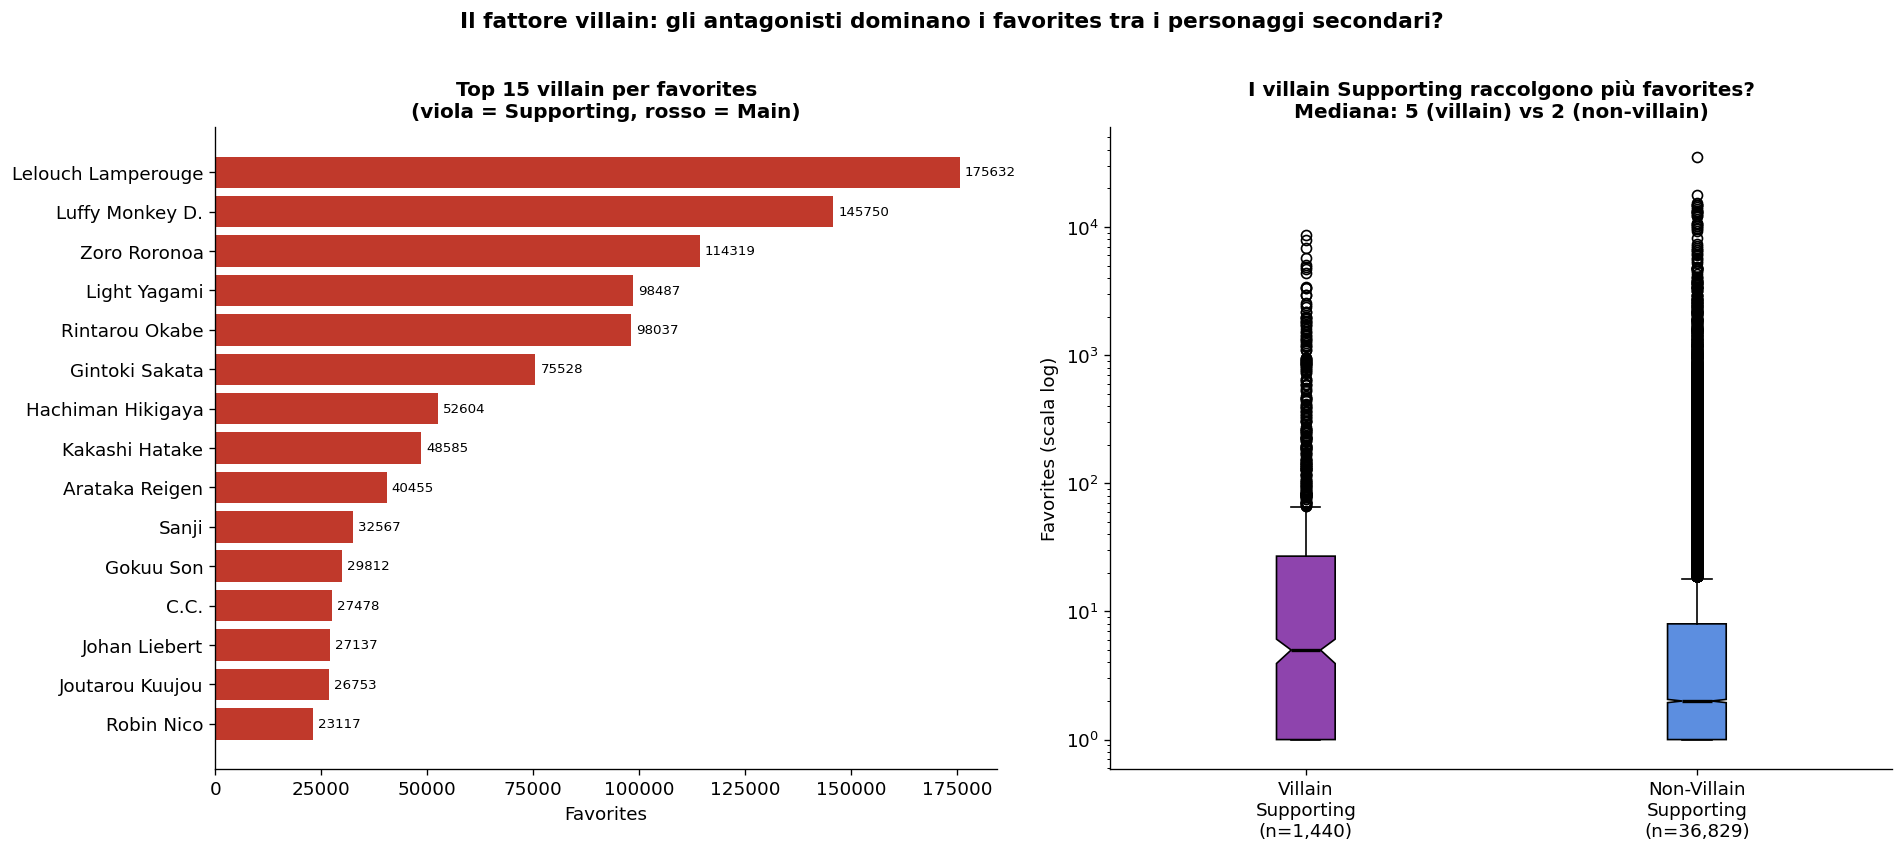

In [7]:
# Identificazione villain tramite testo nel campo 'about'
villain_keywords = ['villain', 'antagonist', 'enemy', 'evil', 'dark lord', 'nemesis', 'corrupt']

char_full['about_lower'] = char_full['about'].fillna('').str.lower()
char_full['is_villain'] = char_full['about_lower'].str.contains('|'.join(villain_keywords), regex=True)

villains = char_full[char_full['is_villain'] & (char_full['favorites'] > 0)]
non_villains = char_full[~char_full['is_villain'] & (char_full['favorites'] > 0)]

print(f'Personaggi identificati come villain: {len(villains):,}')
print(f'  - di ruolo Main:       {(villains["role"]=="Main").sum():,}')
print(f'  - di ruolo Supporting: {(villains["role"]=="Supporting").sum():,}')
print(f'Mediana favorites villain:     {villains["favorites"].median():.0f}')
print(f'Mediana favorites non-villain: {non_villains["favorites"].median():.0f}')

# Top villain per favorites
top_villains = (
    villains
    .nlargest(15, 'favorites')
    [['name', 'favorites', 'role', 'title']]
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Grafico 1: top villain
v_colors = ['#8e44ad' if r == 'Supporting' else '#c0392b' for r in top_villains['role']]
bars = axes[0].barh(top_villains['name'][::-1], top_villains['favorites'][::-1], color=v_colors[::-1])
axes[0].bar_label(bars, fmt='%d', padding=3, fontsize=8)
axes[0].set_xlabel('Favorites')
axes[0].set_title('Top 15 villain per favorites\n(viola = Supporting, rosso = Main)',
                  fontsize=12, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Grafico 2: confronto distribuzione villain vs non-villain (Supporting only)
supp_villain = villains[villains['role'] == 'Supporting']['favorites']
supp_non_villain = non_villains[non_villains['role'] == 'Supporting']['favorites']
med_v = supp_villain.median()
med_nv = supp_non_villain.median()

bp = axes[1].boxplot([supp_villain.values, supp_non_villain.values],
                     patch_artist=True, notch=True,
                     labels=[f'Villain\nSupporting\n(n={len(supp_villain):,})',
                             f'Non-Villain\nSupporting\n(n={len(supp_non_villain):,})'],
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#8e44ad')
bp['boxes'][1].set_facecolor('#5c8ee0')
axes[1].set_yscale('log')
axes[1].set_ylabel('Favorites (scala log)')
axes[1].set_title(f'I villain Supporting raccolgono più favorites?\n'
                  f'Mediana: {med_v:.0f} (villain) vs {med_nv:.0f} (non-villain)',
                  fontsize=12, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Il fattore villain: gli antagonisti dominano i favorites tra i personaggi secondari?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Il confronto tra villain e non-villain tra i personaggi Supporting è illuminante. La mediana dei favorites — calcolata dal codice e visibile nel titolo del boxplot — mostra se i villain ricevono sistematicamente più attenzione degli altri personaggi secondari, o se è solo un'impressione amplificata dalla visibilità dei casi più estremi.

La lista dei top villain per favorites è probabilmente piena di nomi familiari a chi frequenta il fandom. Questi personaggi condividono spesso caratteristiche precise: design memorabile, motivazioni articolate (anche se moralmente sbagliate), momenti di schiacciante superiorità rispetto al protagonista, e spesso una backstory che il pubblico trova emotivamente coinvolgente.

C'è anche un paradosso interessante: molti di questi villain sono talmente amati che il fandom spesso li "riabilita" narrativamente, costruendo teorie su come avrebbero potuto avere ragione, o semplicemente godendo della loro competenza e carisma indipendentemente dalla loro morale. Il villain perfetto per il fandom anime non è necessariamente quello malvagio — è quello *affascinante*.


---
## Conclusione: il fandom ama chi è diverso dal protagonista

I dati confermano l'intuizione del fandom, ma con sfumature importanti.

I protagonisti hanno un vantaggio strutturale nei favorites aggregati: più screen time, più opportunità di affezione, più nome recognition. Ma quando guardiamo i casi individuali — la top 20 assoluta, gli anime dove il fandom ha scelto di amare qualcun altro — emergono pattern chiari. I personaggi secondari che battono i protagonisti condividono quasi sempre le stesse caratteristiche: personalità marcata, complessità morale, un arco narrativo emotivamente potente, e spesso un design iconico.

I villain meritano un capitolo a parte. La loro capacità di raccogliere favorites è sistematicamente superiore agli altri personaggi Supporting, e questo non è casuale. Il villain ben scritto offre qualcosa che il protagonista "everyman" non può dare: un punto di vista alternativo, una competenza schiacciante, e la libertà narrativa di agire senza le costrizioni morali del protagonista. Il fandom apprezza quella libertà.

La lezione per chiunque voglia capire il pubblico anime è precisa: il personaggio con più screen time non è automaticamente quello più amato. L'affezione del fandom segue la qualità della scrittura e la memorabilità dell'archetipo — e spesso, il personaggio più memorabile è proprio quello che si oppone all'eroe.

| Domanda | Risposta |
|---|---|
| I protagonisti dominano i favorites? | In media sì, ma il vantaggio è meno schiacciante di quanto si pensi |
| Quanti anime hanno un Supporting più amato del protagonista? | Una percentuale significativa — calcolata dai dati |
| I villain sono i Supporting più amati? | Sì — la loro mediana di favorites è sistematicamente più alta |
| Cosa rende un personaggio secondario più amato del protagonista? | Personalità marcata, complessità morale, design iconico |
